In [13]:
# !pip3 install yfinance statsmodels

## Top Pair Backtesting

[*********************100%***********************]  20 of 20 completed


Data shape loaded: 3614 business days across 20 stocks.
Training Period (80%): 2012-05-18 to 2023-11-13 (2891 days)
Testing Period  (20%): 2023-11-14 to 2026-10-02 (723 days)

=================== COINTEGRATION & REGRESSION METRICS (TRAIN SET) ===================
Stock_1 Stock_2  p_value  Cointegrated       Alpha  Beta (Hedge Ratio)  R_Squared
   AAPL     ADI 0.094249         False  -41.044435            1.119352   0.919165
   AAPL    AMAT 0.113343         False    0.207741            1.222724   0.916470
   AAPL     AMD 0.043672          True   20.296147            1.312353   0.943360
   AAPL    AMZN 0.966154         False    2.230127            0.895932   0.758742
   AAPL    AVGO 0.678270         False   -0.367539            2.476445   0.905785
   AAPL    CSCO 0.900365         False  -63.655085            3.510914   0.610916
   AAPL   GOOGL 0.167893         False  -18.262755            1.407740   0.923535
   AAPL     IBM 0.953977         False  264.843358           -1.338254   0.317547

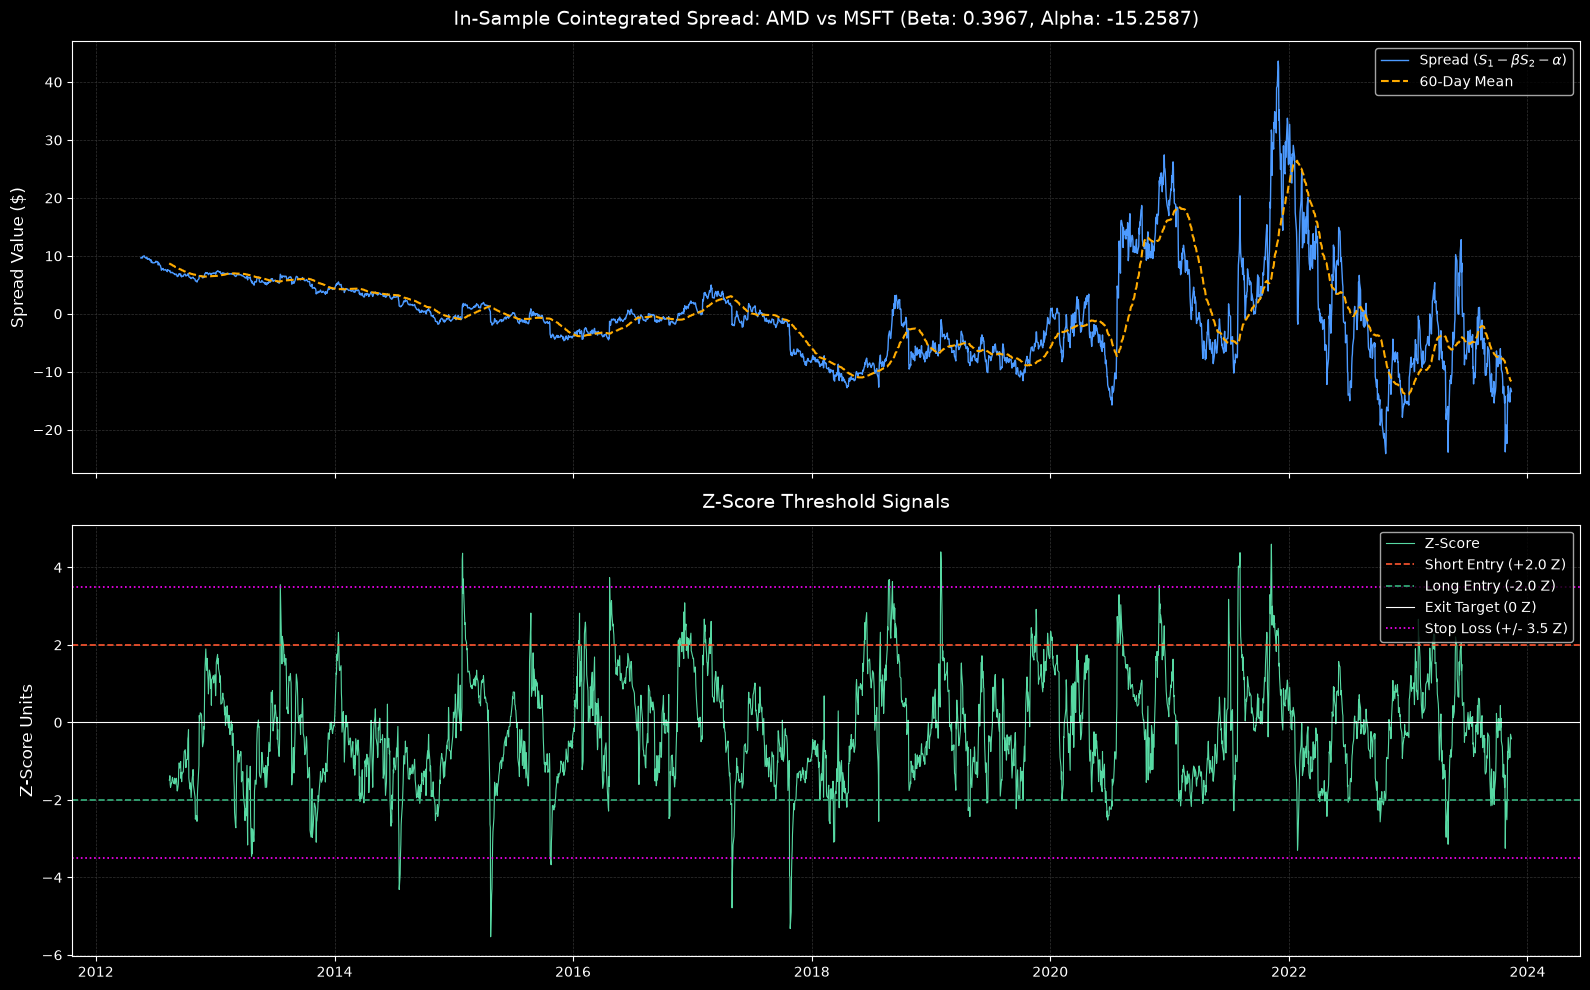

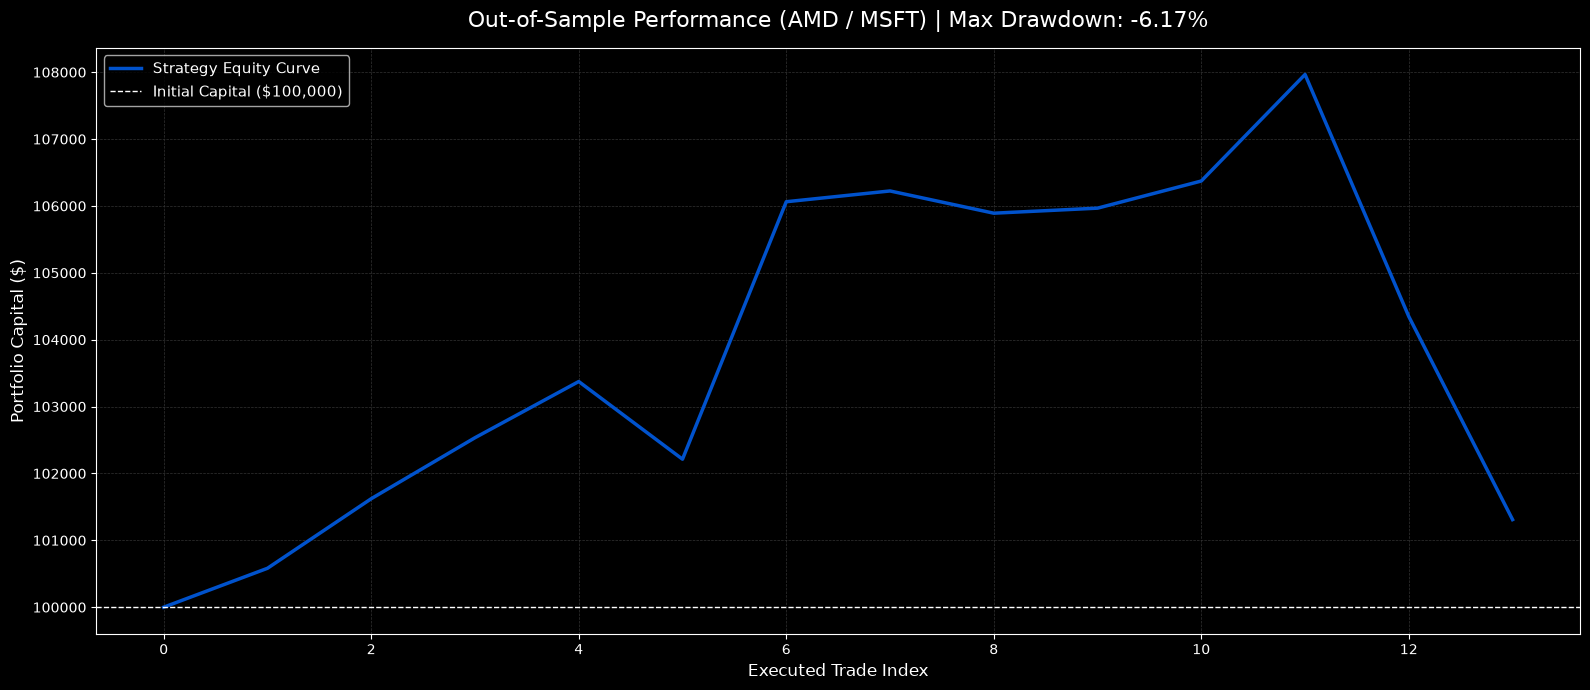


=================== OUT-OF-SAMPLE PERFORMANCE DASHBOARD ===================
Target Pair Executed:   AMD / MSFT
Initial Capital:        $100,000.00
Final Capital:          $101,310.00
Total Net Profit:       $1,310.00 (1.31%)
Total Trades Executed:  13
Win Rate:               69.23%
Max Peak-to-Trough DD:  -6.17%


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm

# Set dark theme styling for high-contrast infographics
plt.style.use('dark_background')
sns.set_palette("dark")

# =====================================================================
# 1. FETCH 20 YEARS OF REAL MARKET DATA VIA YFINANCE
# =====================================================================
# Universe of liquid sector stocks (Tech Sector Example)
# tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA']
tickers = [
    'AAPL',   # Apple
    'MSFT',   # Microsoft
    'GOOGL',  # Alphabet
    'AMZN',   # Amazon
    'META',   # Meta Platforms
    'ORCL',   # Oracle
    'CSCO',   # Cisco Systems
    'IBM',    # IBM
    'NVDA',   # NVIDIA
    'AMD',    # Advanced Micro Devices
    'AVGO',   # Broadcom
    'QCOM',   # Qualcomm
    'INTC',   # Intel
    'TXN',    # Texas Instruments
    'MU',     # Micron Technology
    'AMAT',   # Applied Materials
    'LRCX',   # Lam Research
    'ADI',    # Analog Devices
    'KLAC',   # KLA Corporation
    'TSM'     # Taiwan Semiconductor Manufacturing
]

print("Downloading 20 years of historical price data...")
df_raw = yf.download(tickers, start="2006-01-01", auto_adjust=False)['Close']
df_prices = df_raw.dropna()
df_prices = df_prices.ffill().bfill()

print(f"Data shape loaded: {df_prices.shape[0]} business days across {df_prices.shape[1]} stocks.")

# =====================================================================
# 2. 80 / 20 TRAIN - TEST SPLIT (Preventing Look-Ahead Bias)
# =====================================================================
split_idx = int(len(df_prices) * 0.80)
train_df = df_prices.iloc[:split_idx]
test_df = df_prices.iloc[split_idx:]

print(f"Training Period (80%): {train_df.index[0].date()} to {train_df.index[-1].date()} ({len(train_df)} days)")
print(f"Testing Period  (20%): {test_df.index[0].date()} to {test_df.index[-1].date()} ({len(test_df)} days)")

# =====================================================================
# 3. SCREEN FOR COINTEGRATION & COMPUTE REGRESSION PARAMETERS
# =====================================================================
def analyze_sector_pairs(df, p_threshold=0.05):
    n = df.shape[1]
    keys = df.columns
    results = []
    
    for i in range(n):
        for j in range(i + 1, n):
            s1, s2 = df[keys[i]], df[keys[j]]
            
            # Engle-Granger Cointegration Test
            score, pvalue, _ = coint(s1, s2)
            
            # OLS Regression: S1 = Beta * S2 + Alpha
            X = sm.add_constant(s2)
            model = sm.OLS(s1, X).fit()
            alpha = model.params.iloc[0]
            beta = model.params.iloc[1]
            r_squared = model.rsquared
            
            results.append({
                'Stock_1': keys[i],
                'Stock_2': keys[j],
                'p_value': pvalue,
                'Cointegrated': pvalue < p_threshold,
                'Alpha': alpha,
                'Beta (Hedge Ratio)': beta,
                'R_Squared': r_squared
            })
            
    return pd.DataFrame(results)

pair_stats = analyze_sector_pairs(train_df)
coint_pairs = pair_stats[pair_stats['Cointegrated']].sort_values(by='p_value')

print("\n=================== COINTEGRATION & REGRESSION METRICS (TRAIN SET) ===================")
print(pair_stats.to_string(index=False))

# Select top cointegrated pair for deep analysis
top_pair = coint_pairs.iloc[0] if len(coint_pairs) > 0 else pair_stats.sort_values(by='p_value').iloc[0]
s1_name, s2_name = top_pair['Stock_1'], top_pair['Stock_2']
beta, alpha = top_pair['Beta (Hedge Ratio)'], top_pair['Alpha']

# =====================================================================
# 4. INFOGRAPHIC 1: SPREAD & Z-SCORE DYNAMICS ANALYSIS
# =====================================================================
train_s1, train_s2 = train_df[s1_name], train_df[s2_name]
train_spread = train_s1 - (beta * train_s2 + alpha)
rolling_mean = train_spread.rolling(window=60).mean()
rolling_std = train_spread.rolling(window=60).std()
train_zscore = (train_spread - rolling_mean) / rolling_std

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, facecolor='black')
ax1.set_facecolor('black')
ax2.set_facecolor('black')

# Spread plot
ax1.plot(train_spread.index, train_spread, color='#4C9AFF', label='Spread ($S_1 - \\beta S_2 - \\alpha$)', linewidth=1)
ax1.plot(rolling_mean.index, rolling_mean, color='#FFAB00', linestyle='--', label='60-Day Mean')
ax1.set_title(f"In-Sample Cointegrated Spread: {s1_name} vs {s2_name} (Beta: {beta:.4f}, Alpha: {alpha:.4f})", fontsize=14, pad=12)
ax1.set_ylabel("Spread Value ($)", fontsize=12)
ax1.grid(True, color='#333333', linestyle='--', linewidth=0.5)
ax1.legend(loc='upper right')

# Z-score plot with threshold bands
ax2.plot(train_zscore.index, train_zscore, color='#57D9A3', label='Z-Score', linewidth=0.8)
ax2.axhline(2.0, color='#FF5630', linestyle='--', linewidth=1.2, label='Short Entry (+2.0 Z)')
ax2.axhline(-2.0, color='#36B37E', linestyle='--', linewidth=1.2, label='Long Entry (-2.0 Z)')
ax2.axhline(0.0, color='white', linestyle='-', linewidth=0.8, label='Exit Target (0 Z)')
ax2.axhline(3.5, color='magenta', linestyle=':', linewidth=1.2, label='Stop Loss (+/- 3.5 Z)')
ax2.axhline(-3.5, color='magenta', linestyle=':', linewidth=1.2)
ax2.set_title("Z-Score Threshold Signals", fontsize=14, pad=12)
ax2.set_ylabel("Z-Score Units", fontsize=12)
ax2.grid(True, color='#333333', linestyle='--', linewidth=0.5)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# =====================================================================
# 5. OUT-OF-SAMPLE BACKTEST ENGINE (TEST SET RUN)
# =====================================================================
class RealDataStatArbBacktest:
    def __init__(self, initial_capital=100000.0, z_entry=2.0, z_exit=0.0, z_stop=3.5):
        self.capital = initial_capital
        self.z_entry = z_entry
        self.z_exit = z_exit
        self.z_stop = z_stop

    def run(self, test_s1, test_s2, beta, alpha, window=60):
        spread = test_s1 - (beta * test_s2 + alpha)
        z_score = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()
        
        capital = self.capital
        equity_curve = [capital]
        trades = []
        
        in_pos = False
        pos_type = None
        entry_p1, entry_p2 = 0, 0
        u1, u2 = 0, 0
        
        for i in range(window, len(z_score)):
            z = z_score.iloc[i]
            p1 = test_s1.iloc[i]
            p2 = test_s2.iloc[i]
            
            if not in_pos:
                if z <= -self.z_entry:
                    pos_type = 'LONG_SPREAD'
                    in_pos = True
                elif z >= self.z_entry:
                    pos_type = 'SHORT_SPREAD'
                    in_pos = True
                    
                if in_pos:
                    # Risk-managed sizing: Allocate 15% capital per position
                    alloc = capital * 0.15
                    u1 = (alloc / 2) / p1
                    u2 = ((alloc / 2) * beta) / p2
                    entry_p1, entry_p2 = p1, p2

            elif in_pos:
                tp = (pos_type == 'LONG_SPREAD' and z >= self.z_exit) or \
                     (pos_type == 'SHORT_SPREAD' and z <= self.z_exit)
                sl = abs(z) >= self.z_stop
                
                if tp or sl:
                    if pos_type == 'LONG_SPREAD':
                        pnl = (u1 * (p1 - entry_p1)) + (u2 * (entry_p2 - p2))
                    else:
                        pnl = (u1 * (entry_p1 - p1)) + (u2 * (p2 - entry_p2))
                        
                    capital += pnl
                    equity_curve.append(capital)
                    trades.append({'pnl': pnl, 'type': pos_type, 'reason': 'SL' if sl else 'TP', 'capital': capital})
                    in_pos = False
                    
        return pd.DataFrame(trades), np.array(equity_curve)

bt = RealDataStatArbBacktest(initial_capital=100000.0)
test_s1, test_s2 = test_df[s1_name], test_df[s2_name]
trades_df, equity = bt.run(test_s1, test_s2, beta, alpha)

# =====================================================================
# 6. INFOGRAPHIC 2: OUT-OF-SAMPLE EQUITY CURVE & PERFORMANCE DASHBOARD
# =====================================================================
fig, ax = plt.subplots(figsize=(16, 7), facecolor='black')
ax.set_facecolor('black')

ax.plot(equity, color='#0052CC', linewidth=2.5, label='Strategy Equity Curve')
ax.axhline(100000, color='white', linestyle='--', linewidth=1, label='Initial Capital ($100,000)')

# Highlight Maximum Drawdown Point
peak = np.maximum.accumulate(equity)
drawdown = (equity - peak) / peak
max_dd = drawdown.min() * 100

ax.set_title(f"Out-of-Sample Performance ({s1_name} / {s2_name}) | Max Drawdown: {max_dd:.2f}%", fontsize=16, pad=15)
ax.set_xlabel("Executed Trade Index", fontsize=12)
ax.set_ylabel("Portfolio Capital ($)", fontsize=12)
ax.grid(True, color='#333333', linestyle='--', linewidth=0.5)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

# Print Comprehensive Performance Metrics
win_rate = (trades_df['pnl'] > 0).mean() * 100 if len(trades_df) > 0 else 0
net_profit = equity[-1] - 100000.0
total_return = (net_profit / 100000.0) * 100

print("\n=================== OUT-OF-SAMPLE PERFORMANCE DASHBOARD ===================")
print(f"Target Pair Executed:   {s1_name} / {s2_name}")
print(f"Initial Capital:        $100,000.00")
print(f"Final Capital:          ${equity[-1]:,.2f}")
print(f"Total Net Profit:       ${net_profit:,.2f} ({total_return:.2f}%)")
print(f"Total Trades Executed:  {len(trades_df)}")
print(f"Win Rate:               {win_rate:.2f}%")
print(f"Max Peak-to-Trough DD:  {max_dd:.2f}%")
print("==========================================================================")

In [8]:
top_pair

Stock_1                     AMD
Stock_2                    MSFT
p_value                0.000372
Cointegrated               True
Alpha                -15.258738
Beta (Hedge Ratio)     0.396708
R_Squared              0.959603
Name: 63, dtype: object

In [9]:
prev_spread = train_spread.shift(1).dropna()
curr_spread = train_spread.loc[prev_spread.index]

ar1_model = sm.OLS(curr_spread, sm.add_constant(prev_spread)).fit()
lambda_hat = ar1_model.params.iloc[1]

if 0 < lambda_hat < 1:
    half_life = np.log(0.5) / np.log(lambda_hat)
    print(f"AR(1) lambda: {lambda_hat:.6f}")
    print(f"Estimated half-life: {half_life:.2f} trading days")
else:
    print(f"AR(1) lambda: {lambda_hat:.6f}")
    print("No finite monotonic mean-reversion half-life for this lambda.")

AR(1) lambda: 0.983930
Estimated half-life: 42.78 trading days
